## Bottleneck Analysis

### Objective
This notebook diagnoses where and why delays occur in the procurement approval workflow.

The analysis focuses on:
- stage-wise delay contribution
- bottleneck frequency
- waiting vs processing dominance
- department and vendor effects
- rework-related inefficiencies
- concentration of delay across workflow stages

This notebook is central to the project because it moves beyond general EDA and directly identifies operational bottlenecks.

In [9]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd().parent 
FINAL_DIR = BASE_DIR / "data" / "final"

stage_df = pd.read_csv(FINAL_DIR / "final_stage_level.csv")
request_df = pd.read_csv(FINAL_DIR / "final_request_level.csv")

print("Files loaded successfully!")

Files loaded successfully!


### Stage-Wise Average Delay

In [11]:
stage_delay_summary = (
    stage_df.groupby("Stage")[["Processing_Time", "Waiting_Time", "Total_Stage_Time"]]
    .mean()
    .sort_values("Total_Stage_Time", ascending=False)
    .round(2)
)

stage_delay_summary

,Processing_Time,Waiting_Time,Total_Stage_Time
Stage,,,
Finance Approval,34.64,4.09,38.73
Procurement Review,28.51,3.27,31.78
Manager Approval,11.01,3.26,14.28
Final Approval,10.94,3.26,14.21
Rework to Finance Approval,0.00,4.00,4.00
Rework to Manager Approval,0.00,4.00,4.00
Rework to Procurement Review,0.00,4.00,4.00


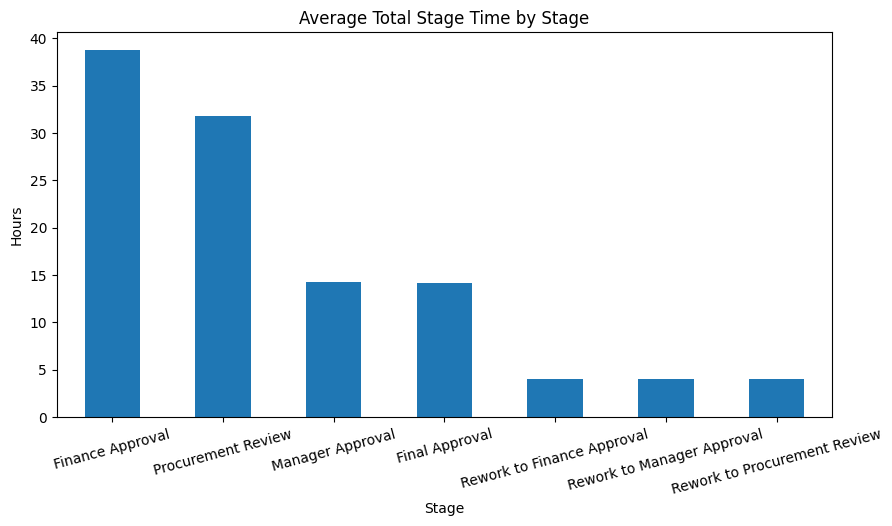

In [13]:
stage_delay_summary["Total_Stage_Time"].plot(kind="bar", figsize=(10, 5))
plt.title("Average Total Stage Time by Stage")
plt.xlabel("Stage")
plt.ylabel("Hours")
plt.xticks(rotation=15)
plt.show()

### Bottleneck Frequency by Stage

In [14]:
bottleneck_counts = request_df["Bottleneck_Stage"].value_counts()
bottleneck_counts

Bottleneck_Stage
Finance Approval      3566
Procurement Review    1425
Manager Approval         7
Final Approval           2
Name: count, dtype: int64

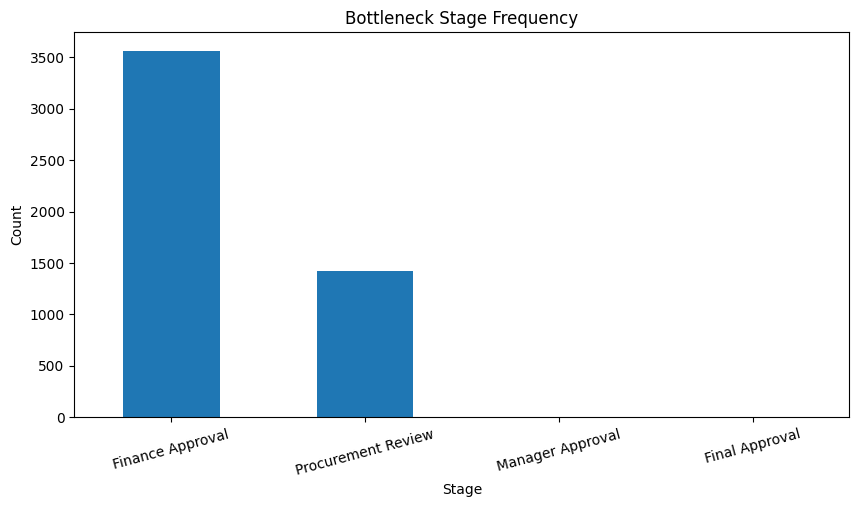

In [15]:
bottleneck_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Bottleneck Stage Frequency")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

### Waiting Time vs Processing Time

In [16]:
waiting_vs_processing = (
    stage_df.groupby("Stage")[["Waiting_Time", "Processing_Time"]]
    .mean()
    .round(2)
)

waiting_vs_processing

,Waiting_Time,Processing_Time
Stage,,
Final Approval,3.26,10.94
Finance Approval,4.09,34.64
Manager Approval,3.26,11.01
Procurement Review,3.27,28.51
Rework to Finance Approval,4.00,0.00
Rework to Manager Approval,4.00,0.00
Rework to Procurement Review,4.00,0.00


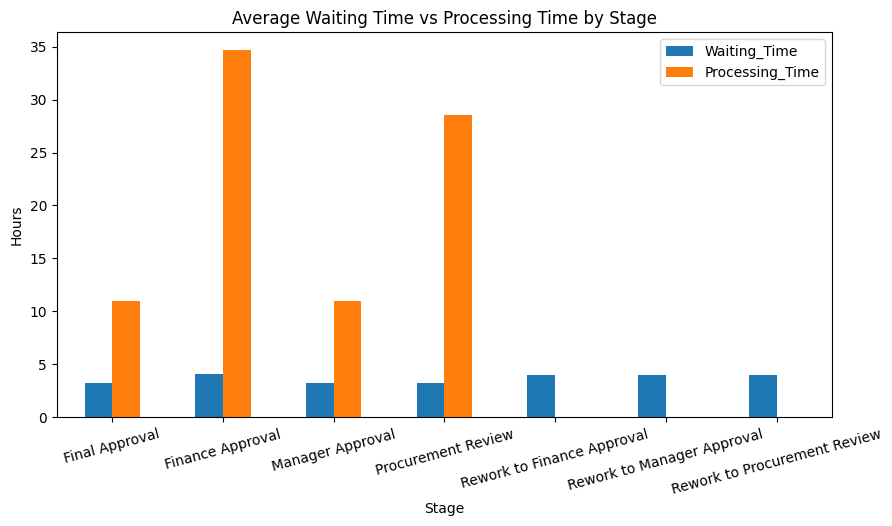

In [17]:
waiting_vs_processing.plot(kind="bar", figsize=(10, 5))
plt.title("Average Waiting Time vs Processing Time by Stage")
plt.xlabel("Stage")
plt.ylabel("Hours")
plt.xticks(rotation=15)
plt.show()

### Department-Wise Delay Behavior

In [18]:
dept_delay = (
    request_df.groupby("Department_Requesting")["Total_TAT"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

dept_delay

Department_Requesting
IT            170.17
Operations    170.08
HR            169.63
Finance       167.61
Admin         165.54
Name: Total_TAT, dtype: float64

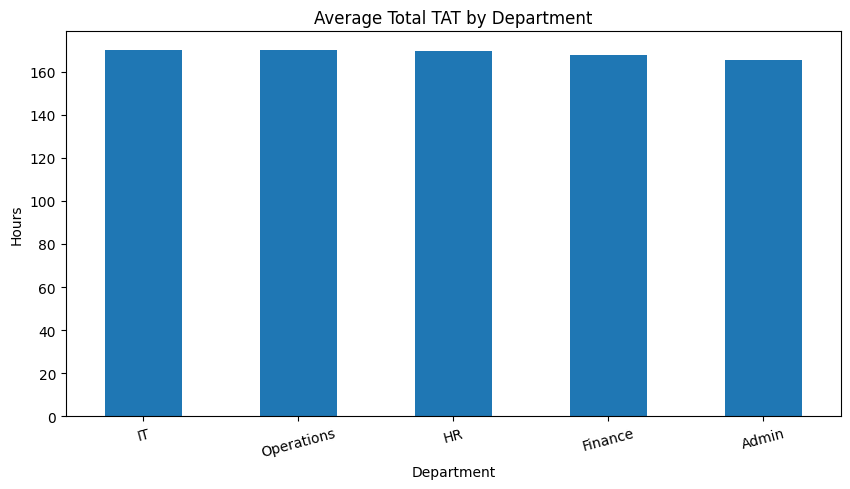

In [19]:
dept_delay.plot(kind="bar", figsize=(10, 5))
plt.title("Average Total TAT by Department")
plt.xlabel("Department")
plt.ylabel("Hours")
plt.xticks(rotation=15)
plt.show()

### Vendor Impact on Turnaround Time

In [20]:
vendor_delay = (
    request_df.groupby("Vendor_Type")["Total_TAT"]
    .mean()
    .round(2)
)

vendor_delay

Vendor_Type
External    174.03
Internal    163.20
Name: Total_TAT, dtype: float64

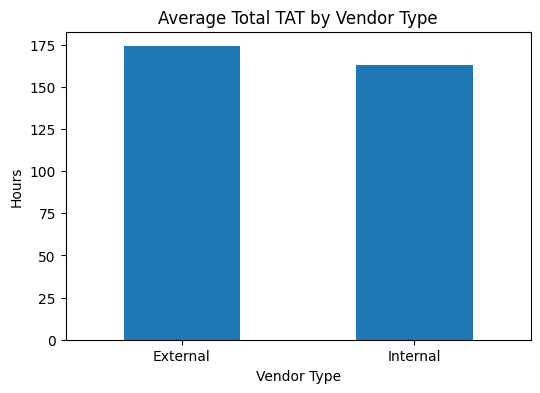

In [21]:
vendor_delay.plot(kind="bar", figsize=(6, 4))
plt.title("Average Total TAT by Vendor Type")
plt.xlabel("Vendor Type")
plt.ylabel("Hours")
plt.xticks(rotation=0)
plt.show()

### Rework Impact

In [22]:
rework_stage_summary = (
    stage_df.groupby("Rework_Flag")["Total_Stage_Time"]
    .mean()
    .round(2)
)

rework_stage_summary

Rework_Flag
0    25.49
1     4.00
Name: Total_Stage_Time, dtype: float64

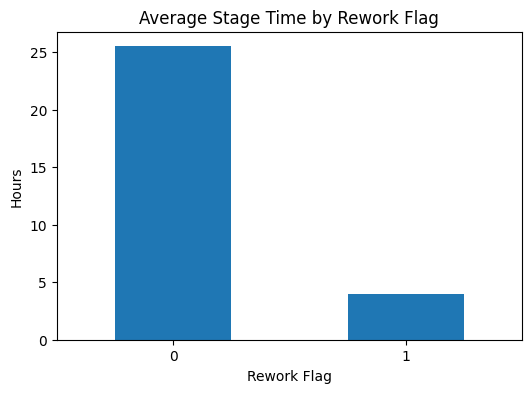

In [23]:
rework_stage_summary.plot(kind="bar", figsize=(6, 4))
plt.title("Average Stage Time by Rework Flag")
plt.xlabel("Rework Flag")
plt.ylabel("Hours")
plt.xticks(rotation=0)
plt.show()

### Delay Conecentration

In [24]:
request_df["Max_Stage_Delay_Share"] = request_df["Max_Stage_Delay"] / request_df["Total_TAT"]
request_df["Max_Stage_Delay_Share"].describe().round(2)

count    5000.00
mean        0.28
std         0.08
min         0.10
25%         0.22
50%         0.29
75%         0.34
max         0.57
Name: Max_Stage_Delay_Share, dtype: float64

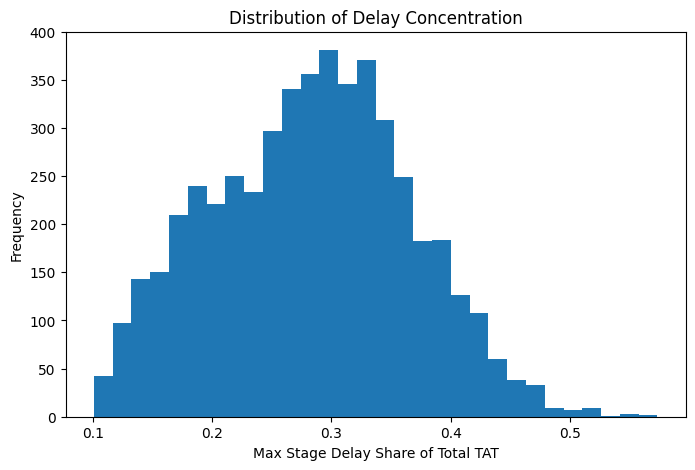

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(request_df["Max_Stage_Delay_Share"].dropna(), bins=30)
plt.title("Distribution of Delay Concentration")
plt.xlabel("Max Stage Delay Share of Total TAT")
plt.ylabel("Frequency")
plt.show()

### Key Findings

- Delays are not evenly distributed across workflow stages  
- Some stages appear more frequently as bottlenecks than others  
- In several stages, waiting time contributes more strongly than active processing time  
- Department-level and vendor-level differences suggest operational variability beyond workflow design alone  
- Rework increases stage time and contributes to recurring inefficiency  
- A large portion of total request delay is often concentrated in a single dominant stage  

These findings confirm that procurement workflow delays are driven by stage dependency and process concentration rather than random variation.

### Conclusion

This bottleneck analysis shows that workflow inefficiency is concentrated, traceable, and operationally meaningful.

Instead of treating delays as a general process issue, the results identify specific stages and request conditions where intervention would have the greatest effect.

This creates a strong basis for targeted managerial action and predictive modeling.